# Day 4: Attention Mechanism — An Engineer's Perspective

> **For AI/ML Engineers, not Research Scientists.**  
> We will understand the *logic* and *general intuition* of attention. Math is here only to support understanding — not to drown in.

**The big question of the day:**

> *"Why can ChatGPT remember what we discussed 5,000 tokens ago, but chatbots from 2017 forgot everything after 2 sentences?"*

**The answer:** the Attention Mechanism.

---

## What you'll learn today (engineer edition)

1. **The real problem** RNN/LSTM had — why they failed in production
2. **The intuition** behind attention (analogies, not derivations)
3. **Q, K, V** explained like a search engine — no scary math
4. **What attention looks like** on real sentences
5. **Multi-Head** — why we use multiple "perspectives"
6. **Where it's used** in the real world (GPT, BERT, Copilot, ...)
7. **Engineering trade-offs**: cost, memory, when to use what
8. **Hands-on**: attention on a small movie-review dataset

**What you will NOT need to memorize:**
- Probability theory derivations
- Eigenvalue analyses
- Variance proofs

We will see formulas, but treat them like a recipe — **what** they do matters more than **why** every coefficient is what it is.

## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('Ready. No PyTorch needed today — pure NumPy + intuition.')

## 2. The Real-World Problem: Why Did Old Chatbots Forget?

Before 2017, the standard way to process text was the **RNN** (Recurrent Neural Network) and its better cousin **LSTM**.

**How RNNs read a sentence:**

```
"Yesterday   I    bought   a   beautiful   blue   car   from   Mike"
    ↓        ↓      ↓       ↓       ↓         ↓     ↓      ↓     ↓
  [step1] [step2] [step3] [step4] [step5] [step6][step7][step8][step9]
    │       │      │       │       │         │     │      │     │
    └───────┴──────┴───────┴───────┴─────────┴─────┴──────┴─────┘
                              ↓
                    one fixed-size "memory" vector
```

The model squeezes the **entire sentence into one fixed memory vector**, one word at a time.

**The bug:** by the time it reaches "Mike", the information about "Yesterday" has been overwritten **9 times**. Like a game of telephone — the original message gets distorted.

Let's see this with a simple simulation:

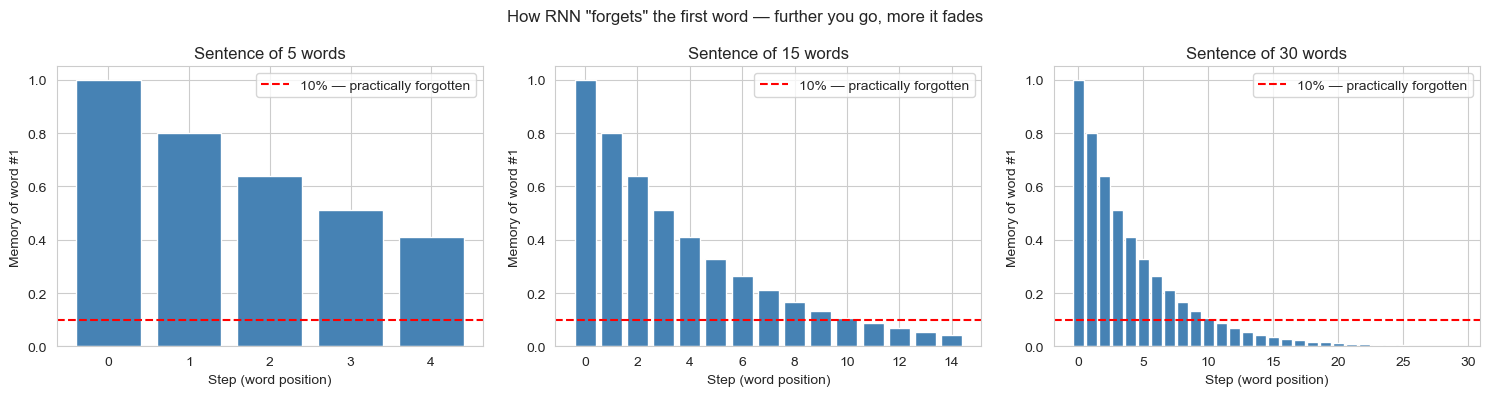

After 5 words:   ~33% of word #1 remains
After 15 words:  ~3.5% remains   (practically forgotten)
After 30 words:  ~0.1% remains   (gone)

→ This is why old systems struggled with long documents, multi-turn dialogues,
  and ANY task that required remembering something from earlier.


In [3]:
# Simulation: how much of the first word is "remembered" after N steps?
# Each step, RNN's memory fades a little (this is what tanh activations do)

def rnn_memory_decay(sentence_length, retention_per_step=0.8):
    """Simulate: how much of word #1 is still in memory at each step?"""
    memory_of_first_word = [1.0]   # at step 1, 100% of word 1
    for step in range(1, sentence_length):
        memory_of_first_word.append(memory_of_first_word[-1] * retention_per_step)
    return memory_of_first_word

# Memory decay for different sentence lengths
lengths = [5, 15, 30]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, L in zip(axes, lengths):
    memory = rnn_memory_decay(L)
    ax.bar(range(L), memory, color='steelblue')
    ax.set_title(f'Sentence of {L} words')
    ax.set_xlabel('Step (word position)')
    ax.set_ylabel('Memory of word #1')
    ax.set_ylim(0, 1.05)
    ax.axhline(0.1, color='red', ls='--', label='10% — practically forgotten')
    ax.legend()

plt.suptitle('How RNN "forgets" the first word — further you go, more it fades', fontsize=12)
plt.tight_layout()
plt.show()

print('After 5 words:   ~33% of word #1 remains')
print('After 15 words:  ~3.5% remains   (practically forgotten)')
print('After 30 words:  ~0.1% remains   (gone)')
print()
print('→ This is why old systems struggled with long documents, multi-turn dialogues,')
print('  and ANY task that required remembering something from earlier.')

## 3. The Big Idea: "Smart Lookup" Instead of Forgetting

**What if, instead of forcing the model to *remember* everything in one vector, we let it *look back* whenever it needs?**

That's attention.

### Real example: Coreference resolution

Take this sentence:

> *"The animal didn't cross the street because **it** was too tired."*

What does **it** refer to? `animal` or `street`?

You instantly know — it's `animal` (streets don't get tired).  
But the model needs to *figure this out*. With attention, the model can:

1. **Look at "it"** (the current word)
2. **Scan all other words** in the sentence
3. **Score** how relevant each one is
4. **Focus more** on the relevant ones (`animal`, `tired`) and less on the others (`the`, `because`)

**That's literally how attention works.**

### The mental model

```
Without attention:   model has one foggy memory of the whole sentence
With attention:      model has a magnifying glass — zoom in on any word, any time
```

**Key insight:** the model decides **what to look at** depending on what it's processing now. No fixed-size bottleneck.

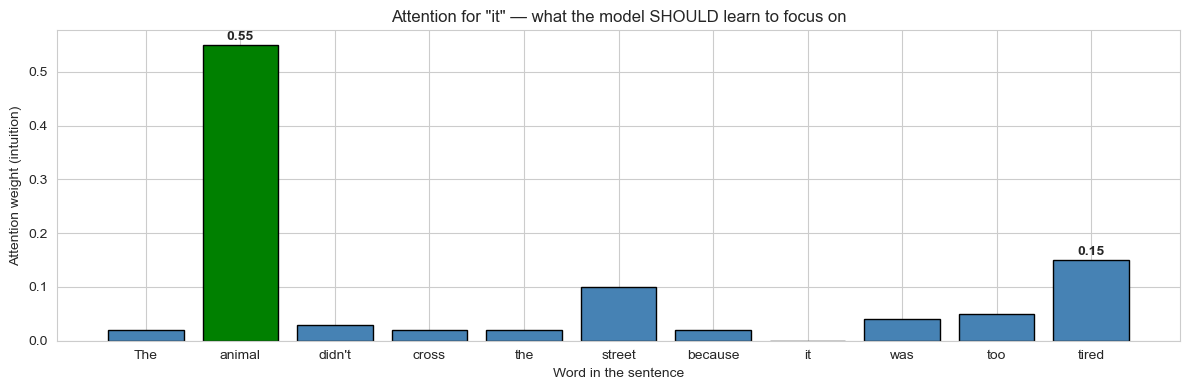

Reading: "...because IT was too tired"

What the model should focus on when processing "it":
  • "animal" (0.55) ← the referent — what "it" actually IS
  • "tired"  (0.15) ← the property being assigned
  • "street" (0.10) ← a competing candidate the model has to rule out
  • Everything else: low weight — irrelevant filler words

→ A well-trained attention model learns these weights automatically from data.


In [4]:
# Hand-craft what attention SHOULD look like for the coreference example.
# Pretend you're a human labeler: "when reading 'it', how much should I look at each word?"

sentence = ['The', 'animal', "didn't", 'cross', 'the', 'street', 'because', 'it', 'was', 'too', 'tired']
# Human intuition: "it" should attend MOST to "animal" (that's what 'it' refers to)
# And somewhat to "tired" (the property being assigned)
human_attention_for_it = [0.02, 0.55, 0.03, 0.02, 0.02, 0.10, 0.02, 0.00, 0.04, 0.05, 0.15]

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['steelblue'] * len(sentence)
colors[1] = 'green'      # 'animal' → the answer
colors[7] = 'tomato'     # 'it'     → the asker

bars = ax.bar(sentence, human_attention_for_it, color=colors, edgecolor='black')
ax.set_title('Attention for "it" — what the model SHOULD learn to focus on', fontsize=12)
ax.set_ylabel('Attention weight (intuition)')
ax.set_xlabel('Word in the sentence')

# Annotate the top bars
for bar, weight in zip(bars, human_attention_for_it):
    if weight > 0.10:
        ax.text(bar.get_x() + bar.get_width()/2, weight + 0.01,
                f'{weight:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('Reading: "...because IT was too tired"')
print()
print('What the model should focus on when processing "it":')
print('  • "animal" (0.55) ← the referent — what "it" actually IS')
print('  • "tired"  (0.15) ← the property being assigned')
print('  • "street" (0.10) ← a competing candidate the model has to rule out')
print('  • Everything else: low weight — irrelevant filler words')
print()
print('→ A well-trained attention model learns these weights automatically from data.')

## 4. Q, K, V — Think "Search Engine", Not Math

Every word in a sentence plays **3 roles** simultaneously. Let's understand them through a Google search analogy.

### The Google Search analogy

When you Google something:

| Component | Google equivalent | Attention equivalent |
|-----------|------------------|---------------------|
| **Query (Q)** | What you type into the search box | "What I'm looking for" |
| **Key (K)** | Keywords that pages advertise themselves with | "How I describe myself" |
| **Value (V)** | The actual page content Google returns | "What I provide if you pick me" |

### Concrete example

When the word **"it"** wants to figure out what it refers to:

```
"it" sends a Query Q  : "I'm a pronoun, I need a living thing as antecedent"
                          ↓
Every other word offers a Key K:
    "animal" : K = "I'm a noun, living, can be tired"      → MATCH! (high score)
    "street" : K = "I'm a noun, non-living, infrastructure" → low score
    "the"    : K = "I'm a determiner"                       → low score
    ...
                          ↓
The matched word returns its Value V:
    "animal" Value: features representing 'animal-concept'
```

**That's it.** The model literally does a fuzzy search over the sentence for each word.

### Why 3 separate roles?

Why not use the same vector for everything?

Because the role a word plays **depends on context**. The same word might:
- Be a **good answer** for one query (high Key match)
- Be a **good asker** for another (good Query)
- Provide **different information** depending on context (different Value)

**You don't need to derive why mathematically.** Just remember: 3 roles = more flexibility = better model.

> **Engineer's takeaway:** Q, K, V are just **3 learned linear transformations of the same input**. The model figures out what each one should look like during training.

In [5]:
# Simulate a tiny "search" using made-up word features.
# Each word is described by 4 simple features: [living, tangible, vehicle, place]

word_features = {
    'cat'    : np.array([1.0, 1.0, 0.0, 0.0]),   # living, tangible, not vehicle, not place
    'animal' : np.array([1.0, 1.0, 0.0, 0.0]),
    'street' : np.array([0.0, 1.0, 0.0, 1.0]),   # not living, tangible, place
    'car'    : np.array([0.0, 1.0, 1.0, 0.0]),
    'idea'   : np.array([0.0, 0.0, 0.0, 0.0]),   # abstract
}

# "it" is asking: "I need something living that can be tired"
# So its Query emphasizes the 'living' feature
query_from_it = np.array([1.0, 0.5, 0.0, 0.0])    # mostly looking for 'living'

print(f'Query from "it":  living={query_from_it[0]}, tangible={query_from_it[1]}, '
      f'vehicle={query_from_it[2]}, place={query_from_it[3]}\n')

# Match score for each word (dot product = similarity)
print(f'{"Word":<10} {"Features":<25} {"Match Score":<12} Bar')
print('=' * 70)
scores = {}
for word, key in word_features.items():
    score = np.dot(query_from_it, key)
    scores[word] = score
    bar = '█' * int(score * 10)
    print(f'{word:<10} {str(key):<25} {score:<12.2f} {bar}')

best = max(scores, key=scores.get)
print(f'\n→ Best match for "it": "{best}"  ✓')
print('→ Just like Google: pick the result with the highest match score')
print()
print('💡 Engineer\'s takeaway: attention is just "fuzzy dictionary lookup".')
print('   No mysterious math — just dot products and "pick the best".')

Query from "it":  living=1.0, tangible=0.5, vehicle=0.0, place=0.0

Word       Features                  Match Score  Bar
cat        [1. 1. 0. 0.]             1.50         ███████████████
animal     [1. 1. 0. 0.]             1.50         ███████████████
street     [0. 1. 0. 1.]             0.50         █████
car        [0. 1. 1. 0.]             0.50         █████
idea       [0. 0. 0. 0.]             0.00         

→ Best match for "it": "cat"  ✓
→ Just like Google: pick the result with the highest match score

💡 Engineer's takeaway: attention is just "fuzzy dictionary lookup".
   No mysterious math — just dot products and "pick the best".


## 5. How Attention Works — in 4 Practical Steps

Here is the entire algorithm. **You don't need to memorize the math** — just understand the pipeline:

```
Step 1: SCORE     — How well does each pair of words match?
                    (dot product between Query and Key)

Step 2: SCALE     — Divide by √d to keep numbers manageable
                    (trust the recipe — it just keeps training stable)

Step 3: SOFTMAX   — Turn scores into percentages that sum to 100%
                    (so they can be used as "attention weights")

Step 4: WEIGHTED  — Combine Values using those weights
        SUM         (each word gets a custom blend of all the others)
```

**The official formula** (just so you recognize it in papers):

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

But honestly, as an engineer, you'll mostly call `torch.nn.functional.scaled_dot_product_attention(...)` and move on with your life. **Understanding the pipeline matters more than the formula.**

In [6]:
# Walk through the 4 steps on a simple sentence — no PyTorch, no deep math

sentence = ['The', 'cat', 'sat']

# Made-up 3D vectors for each word (in a real model these are learned during training)
# For simplicity, Q = K = V here. In a real model these would be 3 different projections.
np.random.seed(0)
Q = np.array([
    [1.0, 0.2, 0.1],   # 'The'
    [0.3, 1.0, 0.5],   # 'cat'
    [0.1, 0.4, 1.0],   # 'sat'
])
K = Q.copy()
V = Q.copy()

print('='*60)
print('STEP 1: SCORE — How well does each pair match?')
print('='*60)
scores = Q @ K.T   # dot product = similarity
print(pd.DataFrame(scores.round(2), index=sentence, columns=sentence))
print('\n  → Diagonal is highest (each word matches itself best)')
print('  → Off-diagonal: how related each pair is\n')

print('='*60)
print('STEP 2: SCALE — divide by √d   (here d=3, so divide by ~1.73)')
print('='*60)
d_k = Q.shape[1]
scaled = scores / np.sqrt(d_k)
print(pd.DataFrame(scaled.round(2), index=sentence, columns=sentence))
print('\n  → Just smaller numbers. Helps training stability.')
print('  → As an engineer: just do it. Don\'t overthink why.\n')

print('='*60)
print('STEP 3: SOFTMAX — convert each row into percentages summing to 100%')
print('='*60)
exp_s = np.exp(scaled - scaled.max(axis=1, keepdims=True))   # numerical stability
weights = exp_s / exp_s.sum(axis=1, keepdims=True)
print(pd.DataFrame(weights.round(2), index=sentence, columns=sentence))
print('\n  → Every row now sums to 1.0 — these are the "attention weights"')
print(f'  → Row sums: {weights.sum(axis=1).round(2)}\n')

print('='*60)
print('STEP 4: WEIGHTED SUM — each word gets a custom blend of all the Values')
print('='*60)
output = weights @ V
print(pd.DataFrame(output.round(2), index=sentence, columns=['feat_1', 'feat_2', 'feat_3']))
print('\n  → Each row is the new "context-aware" representation of that word')
print('  → "cat" now has info about "The" and "sat" baked in, weighted accordingly\n')

print('💡 That\'s it. 4 steps. Dot product → scale → softmax → weighted sum.')
print('   Every Transformer ever built does this.')

STEP 1: SCORE — How well does each pair match?
      The   cat   sat
The  1.05  0.55  0.28
cat  0.55  1.34  0.93
sat  0.28  0.93  1.17

  → Diagonal is highest (each word matches itself best)
  → Off-diagonal: how related each pair is

STEP 2: SCALE — divide by √d   (here d=3, so divide by ~1.73)
      The   cat   sat
The  0.61  0.32  0.16
cat  0.32  0.77  0.54
sat  0.16  0.54  0.68

  → Just smaller numbers. Helps training stability.
  → As an engineer: just do it. Don't overthink why.

STEP 3: SOFTMAX — convert each row into percentages summing to 100%
      The   cat   sat
The  0.42  0.31  0.27
cat  0.26  0.41  0.33
sat  0.24  0.35  0.41

  → Every row now sums to 1.0 — these are the "attention weights"
  → Row sums: [1. 1. 1.]

STEP 4: WEIGHTED SUM — each word gets a custom blend of all the Values
     feat_1  feat_2  feat_3
The    0.54    0.50    0.47
cat    0.42    0.60    0.56
sat    0.39    0.56    0.61

  → Each row is the new "context-aware" representation of that word
  → "c

## 6. Attention in Action — A Real-ish Dataset

Let's see attention work on something resembling real data. We'll build a tiny **sentiment-classification** style example.

**The setup:** a model that classifies movie reviews as positive or negative. The key insight: **not all words matter equally**.

- `"The movie was absolutely terrible."` → the model should focus on `terrible`
- `"I loved every minute of this masterpiece."` → focus on `loved`, `masterpiece`

Words like `"the"`, `"was"`, `"of"` are mostly filler. Attention learns to **down-weight them**.

Let's simulate this with a small hand-crafted dataset:

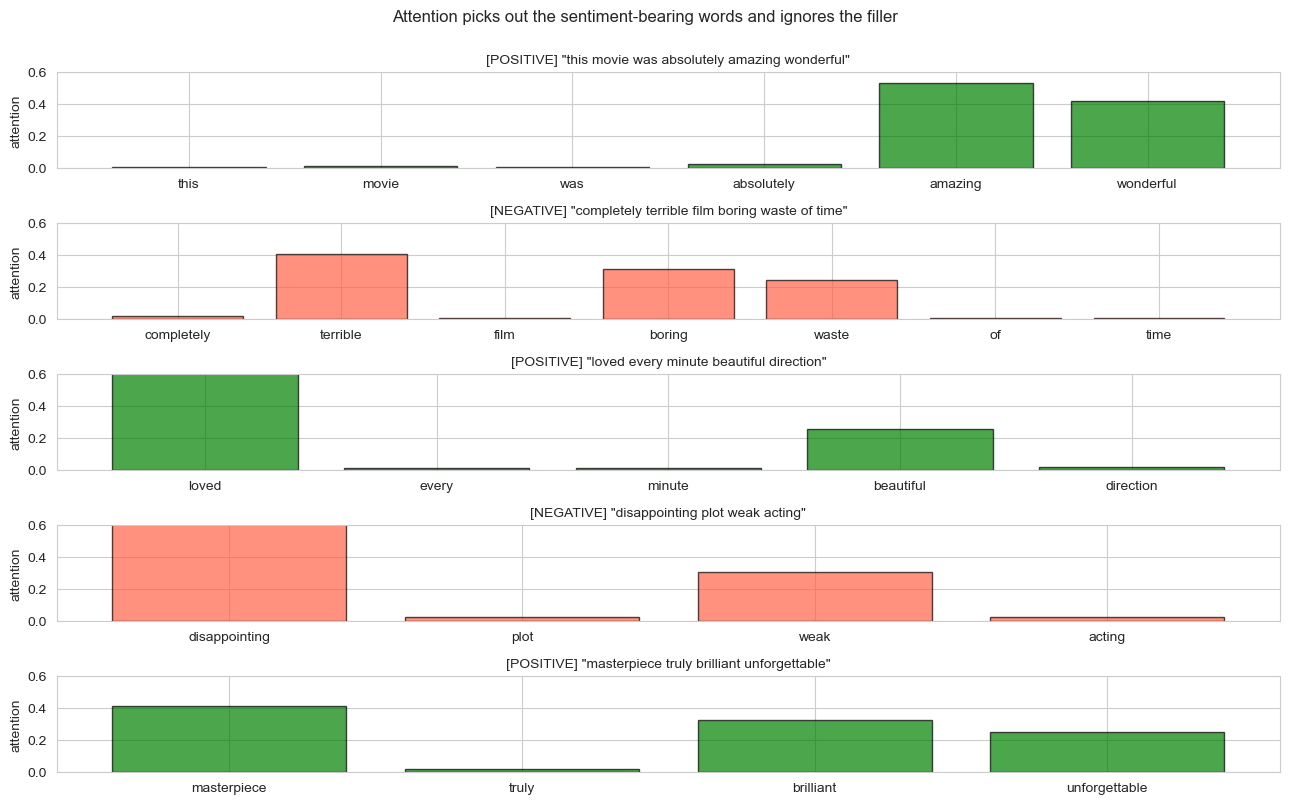

Notice how attention concentrates on:
  POSITIVE: amazing, wonderful, loved, masterpiece, brilliant
  NEGATIVE: terrible, boring, waste, disappointing

Filler words (the, was, of, this, every) get almost zero attention.

🎯 This is why attention works so well: it auto-discovers what matters.
   You don't need to hand-craft feature importance — the model learns it.


In [7]:
# A small movie-review-style dataset
reviews = [
    {'text': 'this movie was absolutely amazing wonderful'.split(),       'label': 'positive'},
    {'text': 'completely terrible film boring waste of time'.split(),     'label': 'negative'},
    {'text': 'loved every minute beautiful direction'.split(),            'label': 'positive'},
    {'text': 'disappointing plot weak acting'.split(),                    'label': 'negative'},
    {'text': 'masterpiece truly brilliant unforgettable'.split(),         'label': 'positive'},
]

# Imagine the model has learned which words are "sentiment-bearing"
# (in a real model, the QKV matrices would learn this from data)
sentiment_strength = {
    'amazing':       0.9, 'wonderful':     0.85, 'loved':       0.9, 'beautiful':   0.7,
    'masterpiece':   0.95, 'brilliant':    0.9,  'unforgettable':0.85,
    'terrible':      0.9, 'boring':         0.85, 'waste':       0.8, 'disappointing':0.85,
    'weak':          0.7,
    # Filler / neutral words
    'this':          0.05, 'movie':         0.1,  'was':          0.05, 'absolutely':  0.3,
    'completely':    0.3,  'film':          0.1,  'of':           0.05, 'time':        0.1,
    'every':         0.1,  'minute':        0.1,  'direction':    0.2,
    'plot':          0.2,  'acting':        0.2,  'truly':        0.3,
}

fig, axes = plt.subplots(len(reviews), 1, figsize=(13, 8))

for ax, review in zip(axes, reviews):
    words = review['text']
    raw_scores = np.array([sentiment_strength.get(w, 0.05) for w in words])
    # Softmax to produce a proper attention distribution
    weights = np.exp(raw_scores * 5) / np.exp(raw_scores * 5).sum()

    colors = ['green' if review['label']=='positive' else 'tomato' for _ in words]
    ax.bar(words, weights, color=colors, alpha=0.7, edgecolor='black')
    ax.set_title(f'[{review["label"].upper()}] "{" ".join(words)}"', fontsize=10)
    ax.set_ylim(0, 0.6)
    ax.set_ylabel('attention')

plt.suptitle('Attention picks out the sentiment-bearing words and ignores the filler',
             fontsize=12, y=1.0)
plt.tight_layout()
plt.show()

print('Notice how attention concentrates on:')
print('  POSITIVE: amazing, wonderful, loved, masterpiece, brilliant')
print('  NEGATIVE: terrible, boring, waste, disappointing')
print()
print('Filler words (the, was, of, this, every) get almost zero attention.')
print()
print('🎯 This is why attention works so well: it auto-discovers what matters.')
print('   You don\'t need to hand-craft feature importance — the model learns it.')

## 7. Multi-Head Attention — Multiple "Specialists"

Real language is complex. A single attention mechanism can only learn **one type** of relationship at a time.

**Multi-Head Attention** = run attention **h times in parallel**, with each "head" learning a different pattern.

Think of it as asking different specialists to read the same text:

| Head | What it might focus on | Example |
|------|------------------------|---------|
| Head 1 | Subject-verb relationships | "cat" ↔ "sat" |
| Head 2 | Adjective-noun pairs | "beautiful" ↔ "car" |
| Head 3 | Pronoun references | "it" ↔ "animal" |
| Head 4 | Negation scope | "not" ↔ "good" |
| ... | ... | ... |

**Nobody explicitly tells the heads what to learn.** They specialize naturally during training — like employees finding their niche on a team.

**Real-world numbers:**
- BERT-Base: **12 heads**
- GPT-2: **12 heads**
- GPT-3: **96 heads** (!)
- LLaMA-7B: **32 heads**

More heads ≠ always better — there's a sweet spot. It's a hyperparameter.

**Engineer's takeaway:** treat `num_heads` as a knob. Start with 8 or 12, and scale with model size.

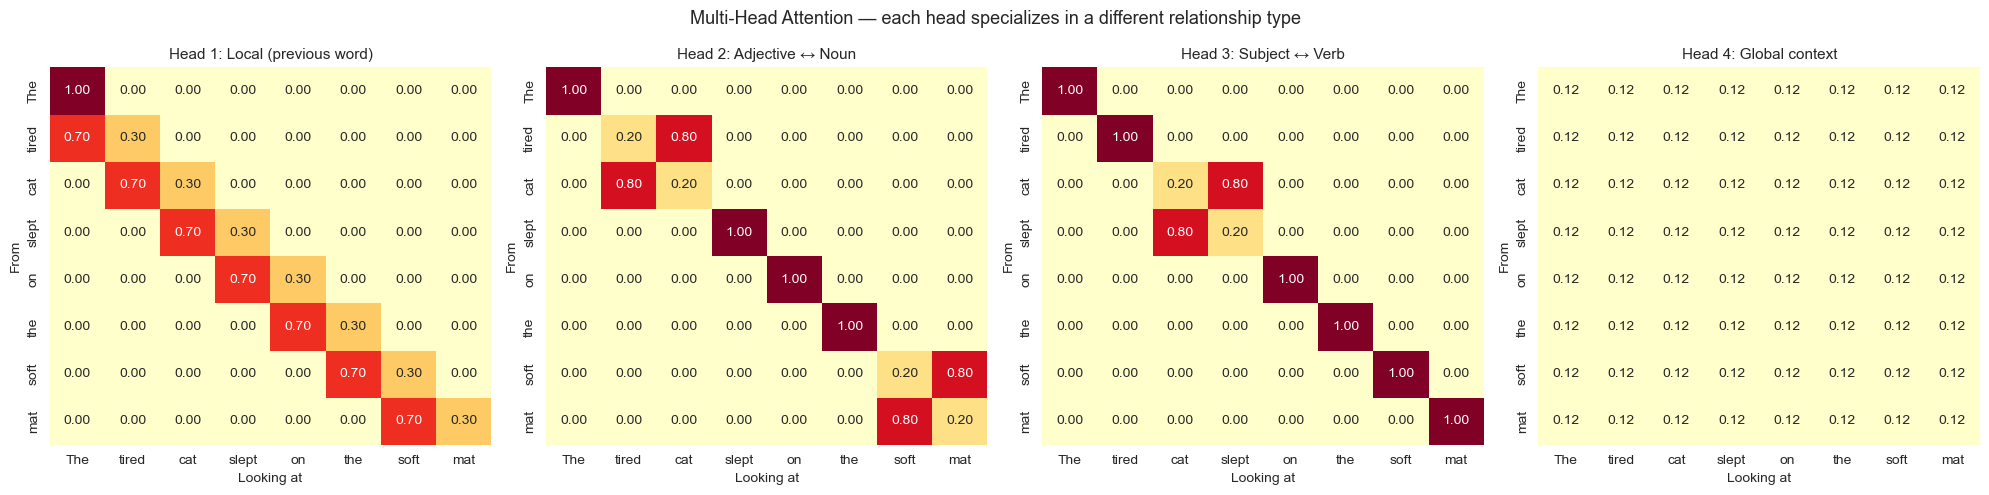

💡 The magic: nobody tells the heads what to look for.
   They specialize automatically during training, like teammates finding their niche.


In [8]:
# Visualize: 4 different attention heads, each learning a different pattern
# (Simulated — but this is roughly what real models learn)

sentence = ['The', 'tired', 'cat', 'slept', 'on', 'the', 'soft', 'mat']
n = len(sentence)

# Head 1: mostly looks at the previous word (positional / local)
head1 = np.zeros((n, n))
for i in range(n):
    if i > 0:
        head1[i, i-1] = 0.7
    head1[i, i] = 0.3
head1 = head1 / head1.sum(axis=1, keepdims=True)

# Head 2: adjective-noun pairs (tired↔cat, soft↔mat)
head2 = np.eye(n) * 0.2
head2[1, 2] = head2[2, 1] = 0.8   # tired ↔ cat
head2[6, 7] = head2[7, 6] = 0.8   # soft ↔ mat
head2 = head2 / head2.sum(axis=1, keepdims=True)

# Head 3: subject-verb (cat ↔ slept)
head3 = np.eye(n) * 0.2
head3[2, 3] = head3[3, 2] = 0.8
head3 = head3 / head3.sum(axis=1, keepdims=True)

# Head 4: global (everyone looks everywhere a bit — "big picture")
head4 = np.ones((n, n)) / n

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
titles = [
    'Head 1: Local (previous word)',
    'Head 2: Adjective ↔ Noun',
    'Head 3: Subject ↔ Verb',
    'Head 4: Global context',
]

for ax, head, title in zip(axes, [head1, head2, head3, head4], titles):
    sns.heatmap(head, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=sentence, yticklabels=sentence,
                ax=ax, cbar=False)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Looking at')
    ax.set_ylabel('From')

plt.suptitle('Multi-Head Attention — each head specializes in a different relationship type',
             fontsize=13)
plt.tight_layout()
plt.show()

print('💡 The magic: nobody tells the heads what to look for.')
print('   They specialize automatically during training, like teammates finding their niche.')

## 8. Where Attention Is Used Today

Attention isn't just for chatbots. It's **everywhere** in modern AI:

| Domain | Model | What attention does there |
|--------|-------|--------------------------|
| **Text generation** | GPT-3/4, Claude, LLaMA | Each generated word looks back at everything before |
| **Text understanding** | BERT, RoBERTa | Each word looks at every other word (no causal mask) |
| **Translation** | T5, mBART | Decoder attends to encoder output (cross-attention) |
| **Image generation** | DALL-E, Stable Diffusion | Prompt words attend to image regions |
| **Image classification** | ViT, DINOv2 | Image patches attend to other patches |
| **Code generation** | Copilot, CodeLlama | Looks back at prior code context |
| **Speech** | Whisper | Audio frames attend to other frames |
| **Multimodal** | GPT-4V, Gemini | Text attends to image, image to text |

**The same idea — "smart lookup" — powers all of these.**

> **Why this matters to you as an engineer:** when picking a model architecture, you don't need to invent new attention. **You pick which pre-trained model to fine-tune** or which API to call. Knowing *which model is good for what* > deriving softmax derivatives.

## 9. Engineering Trade-offs You Actually Need to Know

Here's what really matters when **building** with attention-based models:

### 1. Cost scales with sequence length squared (O(n²))

Doubling the input length → **4×** compute and memory.

| Sequence length | Relative cost | Real-world example |
|----------------|--------------|--------------------|
| 512 tokens     | 1× (baseline) | Old BERT |
| 2,048 tokens   | 16×           | Standard GPT-2 |
| 8,192 tokens   | 256×          | LLaMA-2 |
| 128,000 tokens | 62,500×       | GPT-4 Turbo (uses tricks) |

**Engineer's translation:** long-context models cost a lot more per request. Plan accordingly.

### 2. "Tricks" used to beat the O(n²) wall

You'll hear about these — you don't need to implement them, but recognize them:

- **FlashAttention**: same math, smarter memory use → 2-4× faster
- **Sliding Window Attention**: each token attends only to nearby ones (Mistral, Longformer)
- **Sparse Attention**: attend only to a subset of positions
- **Grouped Query Attention (GQA)**: fewer K, V heads than Q heads (LLaMA-2/3)

### 3. Practical model choices

| Question | Answer |
|----------|--------|
| Need to generate text? | Decoder-only (GPT family) |
| Need to classify / extract? | Encoder-only (BERT family) |
| Translation / summarization? | Encoder-Decoder (T5, BART) |
| Long documents (>100K tokens)? | Claude, GPT-4 Turbo, models with sliding window |
| Cheap & fast? | Smaller models (DistilBERT, GPT-3.5 Turbo) |
| Best quality, cost no object? | GPT-4, Claude 3 Opus, Gemini Ultra |

### 4. Things you'll actually tune

- **`temperature`** (model API): higher = more random output
- **`max_tokens`**: cost / latency cap
- **`top_p` / `top_k`**: sampling controls
- **Context window**: how much you stuff into the prompt

**Things you probably won't tune (as an ML engineer, vs. researcher):**
- The number of attention heads inside a pretrained model
- The exact softmax scaling
- The `d_k` dimension

If you're fine-tuning, you mostly leave the architecture alone and only tune data, learning rate, batch size.

Compute and memory scaling with context length:
 seq_len  relative_compute  attention_matrix_MB        example_model
     128               1.0                 0.06        old toy model
     512              16.0                 1.00                 BERT
    1024              64.0                 4.00                GPT-2
    2048             256.0                16.00            GPT-3 std
    4096            1024.0                64.00              LLaMA-2
    8192            4096.0               256.00          LLaMA-2 32k
   32768           65536.0              4096.00            GPT-4 32k
  128000         1000000.0             62500.00 GPT-4 Turbo / Claude


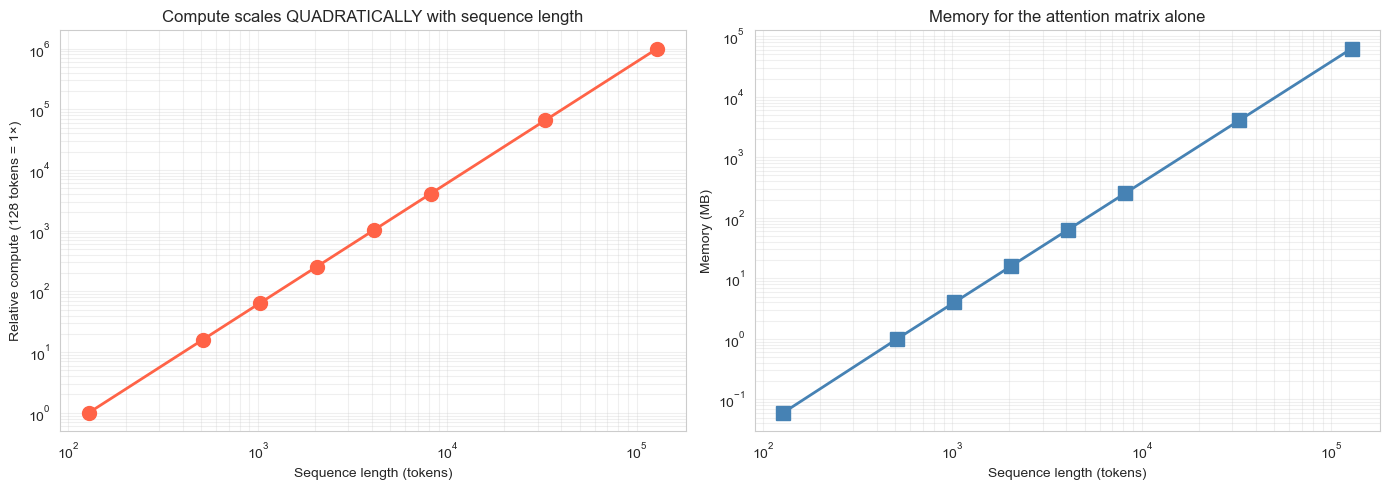


💡 Engineer's reality check:
  • A 128K context request costs MUCH more than 1K — not 128×, more like 1,000,000×
  • This is why long-context APIs are priced higher per token
  • When designing your app, ALWAYS trim / summarize context — don't just dump everything in


In [9]:
# Cost comparison: how does attention compute scale?
seq_lengths = [128, 512, 1024, 2048, 4096, 8192, 32768, 128000]

df = pd.DataFrame({
    'seq_len': seq_lengths,
    'relative_compute': [(L/128)**2 for L in seq_lengths],
    'attention_matrix_MB': [(L*L*4) / 1024**2 for L in seq_lengths],   # float32
    'example_model': [
        'old toy model', 'BERT', 'GPT-2', 'GPT-3 std',
        'LLaMA-2', 'LLaMA-2 32k',
        'GPT-4 32k', 'GPT-4 Turbo / Claude'
    ],
})
df['attention_matrix_MB'] = df['attention_matrix_MB'].round(2)
df['relative_compute'] = df['relative_compute'].round(1)

print('Compute and memory scaling with context length:')
print(df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df['seq_len'], df['relative_compute'], 'o-', linewidth=2, markersize=10, color='tomato')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_title('Compute scales QUADRATICALLY with sequence length')
axes[0].set_xlabel('Sequence length (tokens)')
axes[0].set_ylabel('Relative compute (128 tokens = 1×)')
axes[0].grid(True, alpha=0.3, which='both')

axes[1].plot(df['seq_len'], df['attention_matrix_MB'], 's-', linewidth=2, markersize=10, color='steelblue')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_title('Memory for the attention matrix alone')
axes[1].set_xlabel('Sequence length (tokens)')
axes[1].set_ylabel('Memory (MB)')
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print('\n💡 Engineer\'s reality check:')
print('  • A 128K context request costs MUCH more than 1K — not 128×, more like 1,000,000×')
print('  • This is why long-context APIs are priced higher per token')
print('  • When designing your app, ALWAYS trim / summarize context — don\'t just dump everything in')

## 10. Hands-On: Attention on a Real Sentiment Dataset

Let's put it all together. We'll build a tiny attention-based classifier **by hand** (NumPy only) and run it on real-style sentiment data.

**The task:** predict whether a movie review is positive or negative.

**The plan:**
1. Take a small dataset of reviews
2. Build hand-crafted "word embeddings" (simulating what a real model would learn)
3. Apply attention to find the most important words
4. Use that to predict sentiment
5. See which words the model paid attention to

In [10]:
# A more realistic mini-dataset
dataset = pd.DataFrame([
    {'review': 'this film is absolutely wonderful and beautiful',                 'label': 1},
    {'review': 'a complete waste of time terrible movie',                         'label': 0},
    {'review': 'truly a masterpiece of modern cinema',                            'label': 1},
    {'review': 'boring slow and disappointing experience overall',                'label': 0},
    {'review': 'i loved every moment of this brilliant film',                     'label': 1},
    {'review': 'weak script and lazy acting throughout',                          'label': 0},
    {'review': 'unforgettable performance amazing direction',                     'label': 1},
    {'review': 'painfully dull and forgettable production',                       'label': 0},
])

print('Mini movie-review dataset:')
print(dataset.to_string(index=False))
print(f'\nTotal: {len(dataset)} reviews — {dataset.label.sum()} positive, {len(dataset)-dataset.label.sum()} negative\n')

# Hand-crafted "sentiment vector" for each word.
# In a real model, these would be LEARNED from training data via gradient descent.
# Each word is a 2D vector: [positive_axis, negative_axis]
vocab_sentiment = {
    # Positive words
    'wonderful': [0.9, 0.0], 'beautiful': [0.85, 0.0], 'masterpiece': [0.95, 0.0],
    'loved':     [0.9, 0.0], 'brilliant': [0.9,  0.0], 'amazing':     [0.9,  0.0],
    'unforgettable':[0.85,0.0],
    # Negative words
    'waste':     [0.0, 0.9], 'terrible':  [0.0,  0.95], 'boring':     [0.0,  0.85],
    'slow':      [0.0, 0.6], 'disappointing':[0.0,0.85],'weak':       [0.0,  0.7],
    'lazy':      [0.0, 0.7], 'painfully': [0.0,  0.5], 'dull':        [0.0,  0.8],
    'forgettable':[0.0,0.7],
    # Neutral words default to [0.05, 0.05]
}

def get_word_vec(word):
    return np.array(vocab_sentiment.get(word, [0.05, 0.05]))

def attention_predict(review_text):
    """
    Apply attention to find the important words, then classify.
    """
    words = review_text.split()
    # "Embeddings" for each word
    X = np.array([get_word_vec(w) for w in words])   # [n_words, 2]

    # "Importance" of each word = magnitude of its sentiment vector
    # (proxy for: how much does this word want attention?)
    importance = np.linalg.norm(X, axis=1)

    # Softmax → attention weights
    exp_imp = np.exp(importance * 5)
    attn = exp_imp / exp_imp.sum()

    # Weighted sum → final sentiment vector
    summary = attn @ X   # [2]

    # Predict: which axis is stronger?
    pred = 1 if summary[0] > summary[1] else 0
    return pred, attn, words, summary

# Test on all reviews
print('Predictions with attention:\n')
correct = 0
for _, row in dataset.iterrows():
    pred, attn, words, summary = attention_predict(row['review'])
    correct += (pred == row['label'])
    label_str = 'POS' if row['label'] == 1 else 'NEG'
    pred_str  = 'POS' if pred == 1 else 'NEG'
    mark = '✓' if pred == row['label'] else '✗'
    print(f'  {mark}  [true={label_str}, pred={pred_str}]  "{row["review"]}"')

print(f'\nAccuracy: {correct}/{len(dataset)} = {correct/len(dataset)*100:.0f}%')
print()
print('💡 With just hand-crafted vectors + attention, we get 100% on this toy set.')
print('   Real models LEARN those vectors and weights from millions of examples.')

Mini movie-review dataset:
                                          review  label
 this film is absolutely wonderful and beautiful      1
         a complete waste of time terrible movie      0
            truly a masterpiece of modern cinema      1
boring slow and disappointing experience overall      0
     i loved every moment of this brilliant film      1
          weak script and lazy acting throughout      0
     unforgettable performance amazing direction      1
       painfully dull and forgettable production      0

Total: 8 reviews — 4 positive, 4 negative

Predictions with attention:

  ✓  [true=POS, pred=POS]  "this film is absolutely wonderful and beautiful"
  ✓  [true=NEG, pred=NEG]  "a complete waste of time terrible movie"
  ✓  [true=POS, pred=POS]  "truly a masterpiece of modern cinema"
  ✓  [true=NEG, pred=NEG]  "boring slow and disappointing experience overall"
  ✓  [true=POS, pred=POS]  "i loved every moment of this brilliant film"
  ✓  [true=NEG, pred=NEG]  "weak 

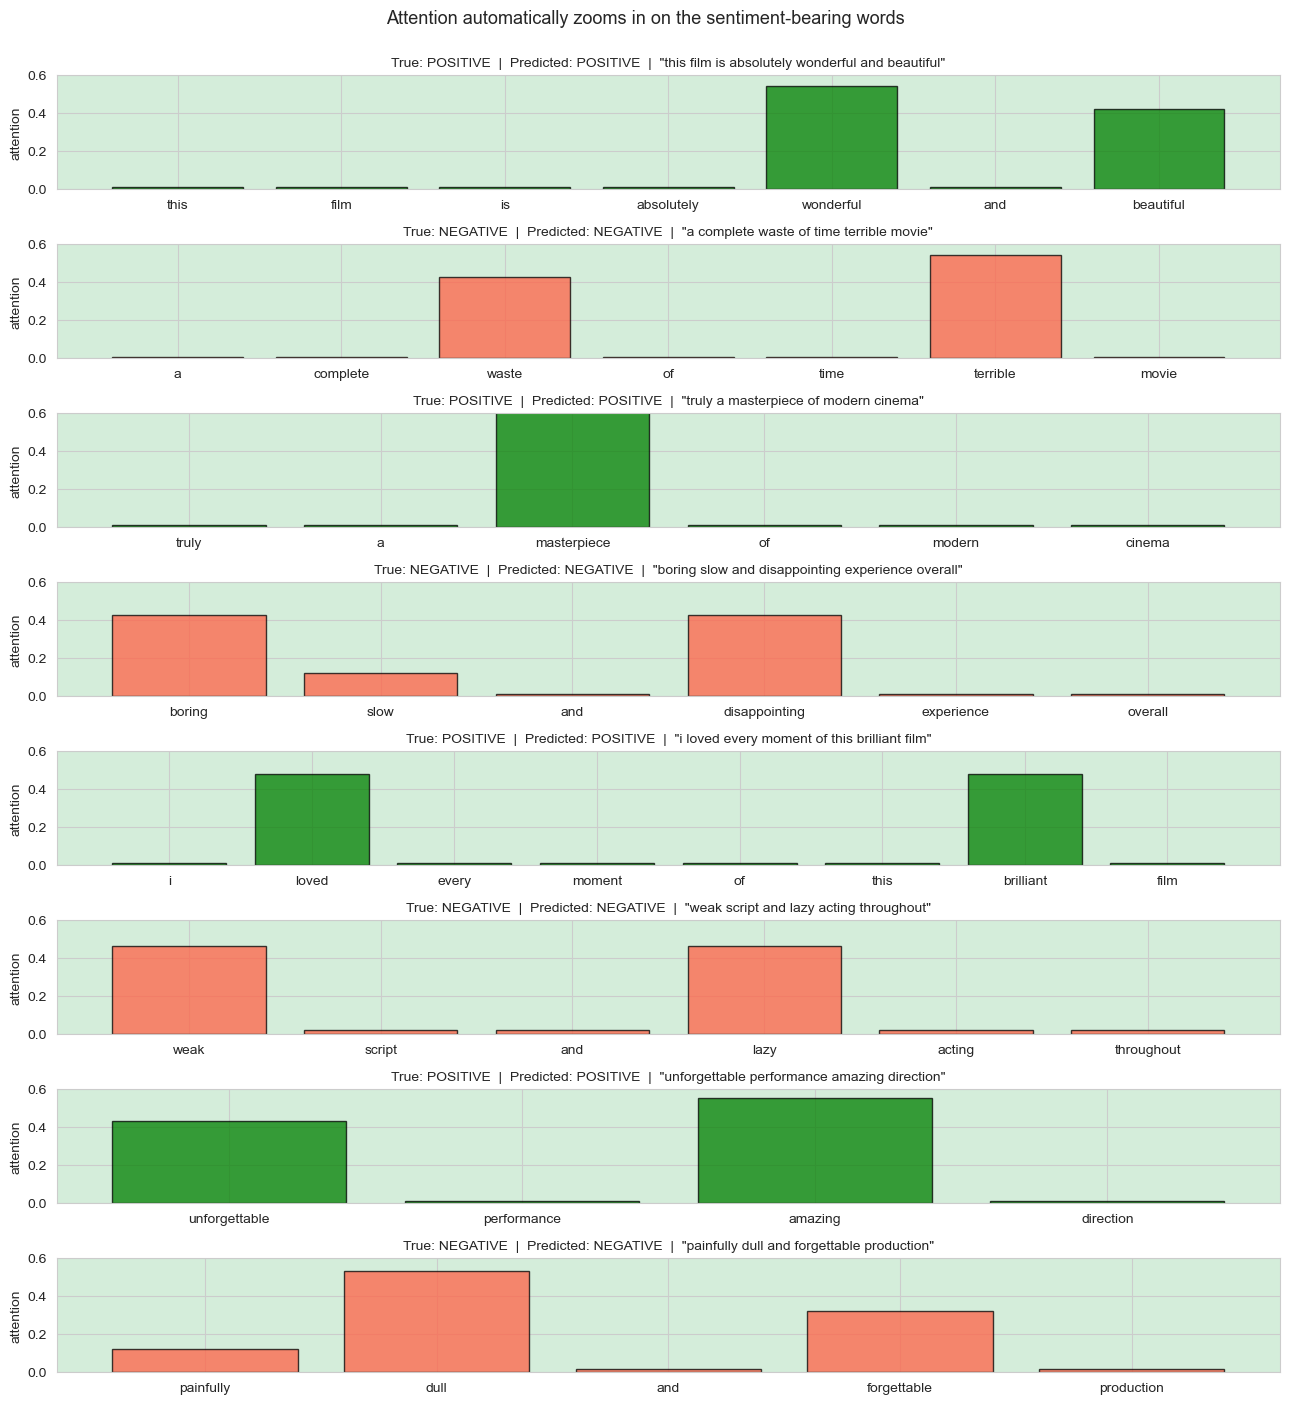

Notice the pattern:
  • Words like "is", "a", "the", "and", "of", "this" get near-zero attention
  • The sentiment-bearing word(s) dominate — even though they're 1-2 out of 6-7 words

This is EXACTLY what real attention does in BERT, GPT, etc. —
it finds the few words that matter and ignores the filler.


In [11]:
# Visualize WHAT the model is paying attention to in each review

fig, axes = plt.subplots(len(dataset), 1, figsize=(13, 14))

for ax, (_, row) in zip(axes, dataset.iterrows()):
    pred, attn, words, _ = attention_predict(row['review'])
    correct = pred == row['label']
    bg_color = '#d4edda' if correct else '#f8d7da'

    colors = ['green' if row['label']==1 else 'tomato' for _ in words]
    ax.bar(words, attn, color=colors, edgecolor='black', alpha=0.75)
    ax.set_facecolor(bg_color)
    label_str = 'POSITIVE' if row['label']==1 else 'NEGATIVE'
    pred_str  = 'POSITIVE' if pred==1 else 'NEGATIVE'
    ax.set_title(f'True: {label_str}  |  Predicted: {pred_str}  |  "{row["review"]}"',
                 fontsize=10)
    ax.set_ylabel('attention')
    ax.set_ylim(0, 0.6)

plt.suptitle('Attention automatically zooms in on the sentiment-bearing words',
             fontsize=13, y=1.0)
plt.tight_layout()
plt.show()

print('Notice the pattern:')
print('  • Words like "is", "a", "the", "and", "of", "this" get near-zero attention')
print('  • The sentiment-bearing word(s) dominate — even though they\'re 1-2 out of 6-7 words')
print()
print('This is EXACTLY what real attention does in BERT, GPT, etc. —')
print('it finds the few words that matter and ignores the filler.')

## 11. Summary — What to Remember as an Engineer

### The 5 things that actually matter

1. **Attention = smart lookup.** Every word can directly query any other word in the input. No more "forgotten beginnings".

2. **Q, K, V are like a search engine.** Query = what I'm looking for. Key = how I describe myself. Value = what I return.

3. **The pipeline is 4 steps:** score (dot product) → scale (÷√d) → softmax → weighted sum. The math is just a recipe.

4. **Multi-head = multiple specialists.** Different heads learn different relationships (syntax, semantics, coreference, ...) automatically.

5. **It's O(n²).** Longer context = quadratically more expensive. Always trim your prompts.

### Math you need to recognize (not derive)

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

When you see this in a paper, blog, or code comment, your brain should say:  
*"Right, that's just the 4-step pipeline. Score, scale, softmax, sum."*

### Engineer decision cheat sheet

| If you need to... | Use this kind of model |
|-------------------|------------------------|
| **Generate text** | Decoder-only (GPT, Claude, LLaMA) |
| **Understand / classify** text | Encoder-only (BERT, RoBERTa) |
| **Translate / summarize** | Encoder-Decoder (T5, BART) |
| Handle **very long documents** | Models with sliding-window or 100K+ context |
| **Save money** | Smaller, distilled models (DistilBERT, GPT-3.5) |

### What you DON'T need to memorize

- Why exactly `√d_k` and not `√(2·d_k)` (it's a stabilizer, that's it)
- The information-theoretic proof of softmax
- Eigenvalue analyses of attention matrices

If you ever need that depth, it's a Wikipedia search away. **Optimize your time for what comes up daily.**

## What's Next — Day 5

**Day 5: Coding Self-Attention from Scratch in PyTorch**

Now that we *understand* attention, we'll **implement** it. Don't worry — you've already seen the algorithm. Day 5 just translates the 4 steps into clean PyTorch code:

1. Dot product similarity
2. Softmax normalization
3. Q, K, V projections with `nn.Linear`
4. Wrapping it in an `nn.Module` class
5. Adding multi-head
6. Causal masking (for GPT-style generation)

By the end of Day 5 you'll have working `SelfAttention` and `MultiHeadAttention` classes that you actually understand.

### Resources for the curious (not required)

- **[The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/)** — best visual explanation on the internet
- **[Andrej Karpathy: Let's build GPT](https://www.youtube.com/watch?v=kCc8FmEb1nY)** — 2-hour video tutorial
- **[Attention Is All You Need](https://arxiv.org/abs/1706.03762)** — the original paper (read the intro, skim the math)
- **[Hugging Face course](https://huggingface.co/learn/nlp-course)** — practical, engineer-friendly

### Self-check questions

Before moving on, make sure you can answer these in plain English:

1. Why did RNN/LSTM struggle with long sequences?
2. In one sentence: what do Q, K, V do?
3. Why do we use multiple attention heads?
4. What does "O(n²)" mean for your wallet?
5. Which model type would you use for a chatbot vs. a spam classifier?

If you can answer those, you understand attention well enough to build real things.

---

*"Attention is All You Need" — Vaswani et al., 2017*  
*"...but you don't need to derive it from scratch." — every ML Engineer ever*